# Sentiment Analysis:

## Bibliotecas Necessárias:

In [69]:
import pandas as pd

## pip install scikit-learn
from sklearn.feature_extraction.text import CountVectorizer 

## Separa os dados para treinamento e teste
from sklearn.model_selection import train_test_split

## Regressão Çogística
from sklearn.linear_model import LogisticRegression

## Nuvem de palavras
from wordcloud import WordCloud

import matplotlib.pyplot as plt

import nltk
from nltk import tokenize

import seaborn as sns


## Inicialização dos dados

In [25]:
df = pd.read_csv("./dataset_avaliacoes.csv")

In [26]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [27]:
df.shape

(15501, 4)

In [28]:
df.value_counts('sentimento')

sentimento
positivo    7890
negativo    7611
dtype: int64

* Exemplo de avaliações:

In [29]:
print("AVALIAÇÃO POSITIVA")

df.avaliacao[0]

AVALIAÇÃO POSITIVA


'Esse smartphone superou minhas expectativas, recomendo'

In [30]:
print("AVALIAÇÃO  NEGATIVA")

df.avaliacao[1]

AVALIAÇÃO  NEGATIVA


'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..'

## Transformando textos em dados numéricos:

* Bag Of Words (EXEMPLO DE USO):

In [31]:
texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()

bag = vetorizar.fit_transform(texto)

In [32]:
bag

<2x5 sparse matrix of type '<class 'numpy.int64'>'
	with 8 stored elements in Compressed Sparse Row format>

In [33]:
matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag, columns=vetorizar.get_feature_names_out())

In [34]:
matriz_esparsa

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


* Bag Of Words (APLICAÇÃO):

In [35]:
# max_features: Pega as palavras com as maiores frequências no dataset para montar a matriz esparsa
vectorizer = CountVectorizer(lowercase=False, max_features=50)

bag_of_words = vectorizer.fit_transform(df.avaliacao)

print(bag_of_words.shape)

(15501, 50)


In [36]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vectorizer.get_feature_names_out())

matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## Separando os dados em conjunto de treino e teste:

In [37]:
X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, df.sentimento, random_state=4978)

In [38]:
# Usando regressão logística
regressao_logistica = LogisticRegression()

regressao_logistica.fit(X_treino, y_treino)

acuracia = regressao_logistica.score(X_teste, y_teste)

print(acuracia)

0.7979876160990712


In [39]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, texto[coluna_classificacao], random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.2f}%")

In [40]:
classificar_texto(df, 'avaliacao', 'sentimento')

Acurácia do modelo com 'avaliacao': 79.80%


## Nuvem de palavras:

In [20]:
all_words = [texto for texto in df.avaliacao]

print(all_words[0])

Esse smartphone superou minhas expectativas, recomendo


In [ ]:
all_words_joined = ' '.join([texto for texto in df.avaliacao])

print(all_words_joined)

Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancelam

* Nuvem de palavras

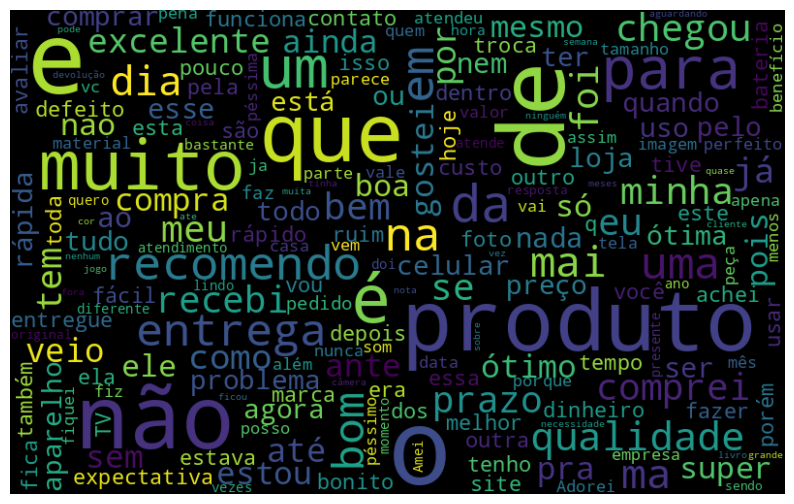

In [46]:
wordcloud = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(all_words_joined)
plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

* Função para filtragem da nuvem:

In [47]:
def nuvem_palavras(texto, coluna_texto, sentimento):
    texto_sentimento = texto.query(f"sentimento == '{sentimento}'")[coluna_texto]
    texto_sentimento_unido = ' '.join(texto_sentimento)

    nuvem = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_sentimento_unido)

    plt.figure(figsize=(10,7))
    plt.imshow(nuvem, interpolation='bilinear')
    plt.axis('off')
    plt.show()

* Nuvem de palavras (POSITIVAS):

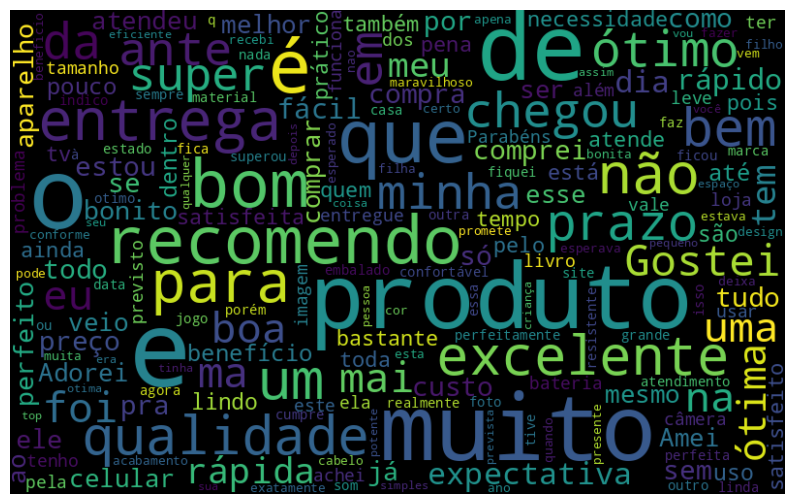

In [48]:
nuvem_palavras(df, 'avaliacao', 'positivo')

* Nuvem de palavras (NEGATIVAS):

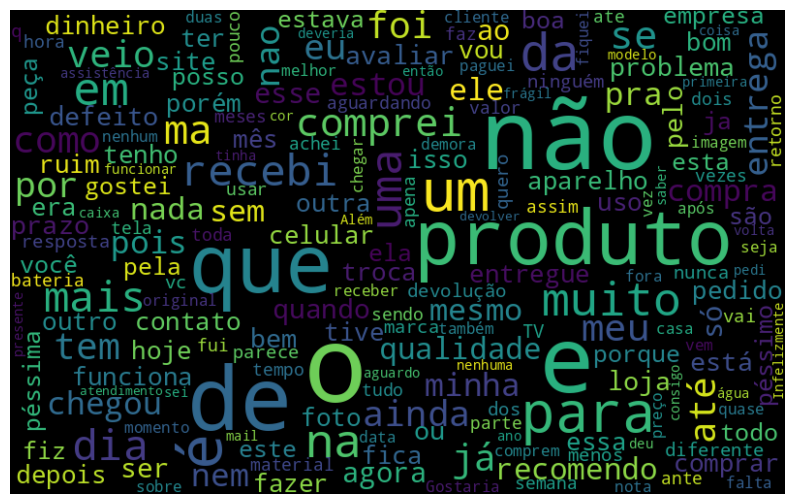

In [49]:
nuvem_palavras(df, 'avaliacao', 'negativo')

## TOKENIZAÇÂO

In [53]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru

True

* Exemplo de tokenização

In [58]:
frases = ['Um produto bom', 'Um produto ruim']

frequencia = nltk.FreqDist(frases)

frequencia

FreqDist({'Um produto bom': 1, 'Um produto ruim': 1})

In [60]:
frase = 'O produto é excelente e a entrega foi muito rápida!'

token_espaco = tokenize.WhitespaceTokenizer()

token_frase = token_espaco.tokenize(frase)

token_frase

['O',
 'produto',
 'é',
 'excelente',
 'e',
 'a',
 'entrega',
 'foi',
 'muito',
 'rápida!']

* Implementação da tokenização aos dados

In [62]:
token_frase = token_espaco.tokenize(all_words_joined)

token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas,',
 'recomendo',
 'o',
 'cheiro',
 'e',
 'muito',
 'desagradavel!!',
 'pra',
 'quem',
 'se',
 'incomoda',
 'nao',
 'recomendoo..',
 'Eu',
 'fiz',
 'a',
 'compra',
 'a',
 'loja',
 'não',
 'entregou',
 'o',
 'produto,',
 'a',
 'compra',
 'foi',
 'feita',
 'no',
 'cartão',
 'de',
 'credito',
 'e',
 'ate',
 'o',
 'momento',
 'a',
 'loja',
 'também',
 'nao',
 'me',
 'devolveu',
 'o',
 'valor',
 'da',
 'compra.',
 'Atendeu',
 'minhas',
 'expectativas,',
 'só',
 'achei',
 'a',
 'luz',
 'ruim,',
 'mas',
 'nada',
 'que',
 'dificulte',
 'seu',
 'funcionamento.',
 'Gostei',
 'muito,',
 'só',
 'achei',
 'que',
 'ficou',
 'a',
 'desejar',
 'a',
 'qualidade',
 'das',
 'fotos.',
 'Achei',
 'que',
 'fosse',
 'bem',
 'melhor',
 '.',
 'Comprei',
 'o',
 'produto',
 'e',
 'ñ',
 'tinha',
 'para',
 'entrega',
 'isso',
 'não',
 'foi',
 'legal!!!!!!',
 'o',
 'produto',
 'pode',
 'até',
 'ser',
 'bom',
 ',mais',
 'só',
 'posso',
 'avalia-lo',
 'depo

In [63]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [67]:
df_frequencia = pd.DataFrame({
    'Palavra': list(frequencia.keys()),
    'Frequência': list(frequencia.values())
})

df_frequencia.head()

,Palavra,Frequência
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


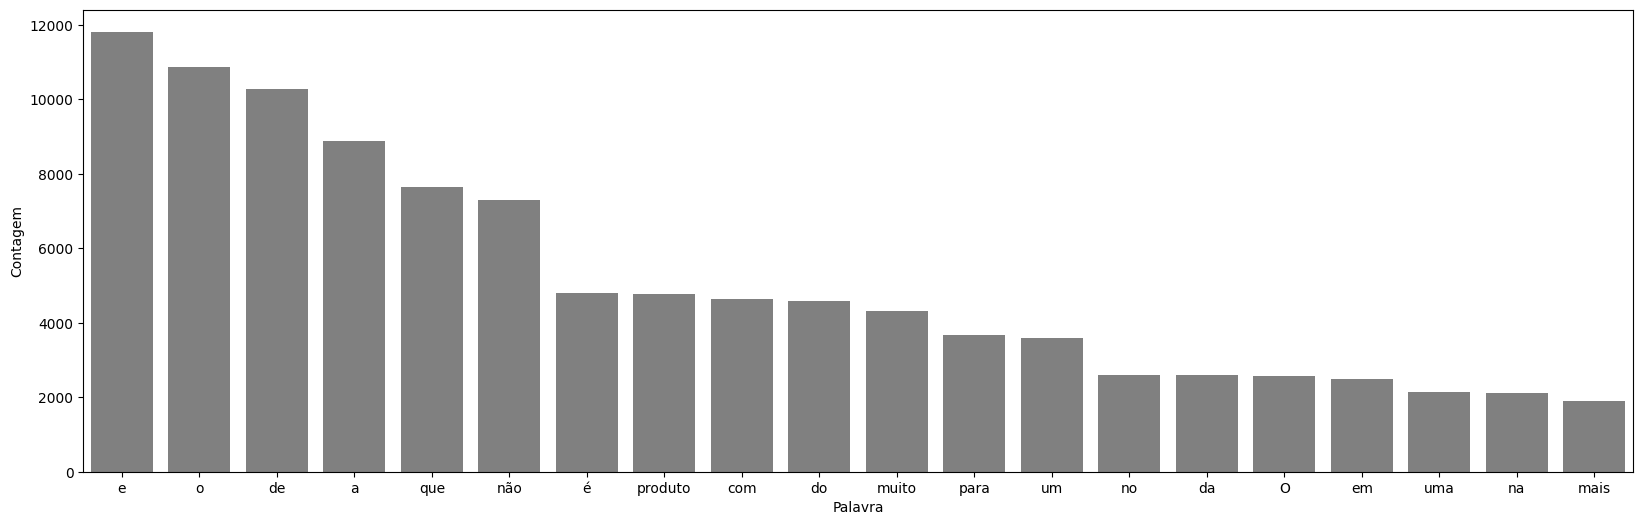

In [73]:
plt.figure(figsize=(20, 6))
ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequência', n=20), x='Palavra', y='Frequência', color='gray')
ax.set(ylabel='Contagem')
plt.show()


* Função para visualizar a frequência de palavras em um dataset

In [74]:
def grafico_frequencia(texto, coluna_texto, quantidade):  
    # Juntando todos os textos em uma única string
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])
    
    # Calculando a frequência das palavras
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    
    # Criando um DataFrame com as palavras e suas frequências
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),
                                  "Frequência": list(frequencia.values())})
    
    # Selecionando as palavras mais frequentes
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)
    
    # Criando o gráfico de barras
    plt.figure(figsize=(20,6))
    ax = sns.barplot(data=df_frequencia, x="Palavra", y="Frequência", color='gray')
    ax.set(ylabel="Contagem")
    
    # Exibindo o gráfico
    plt.show()

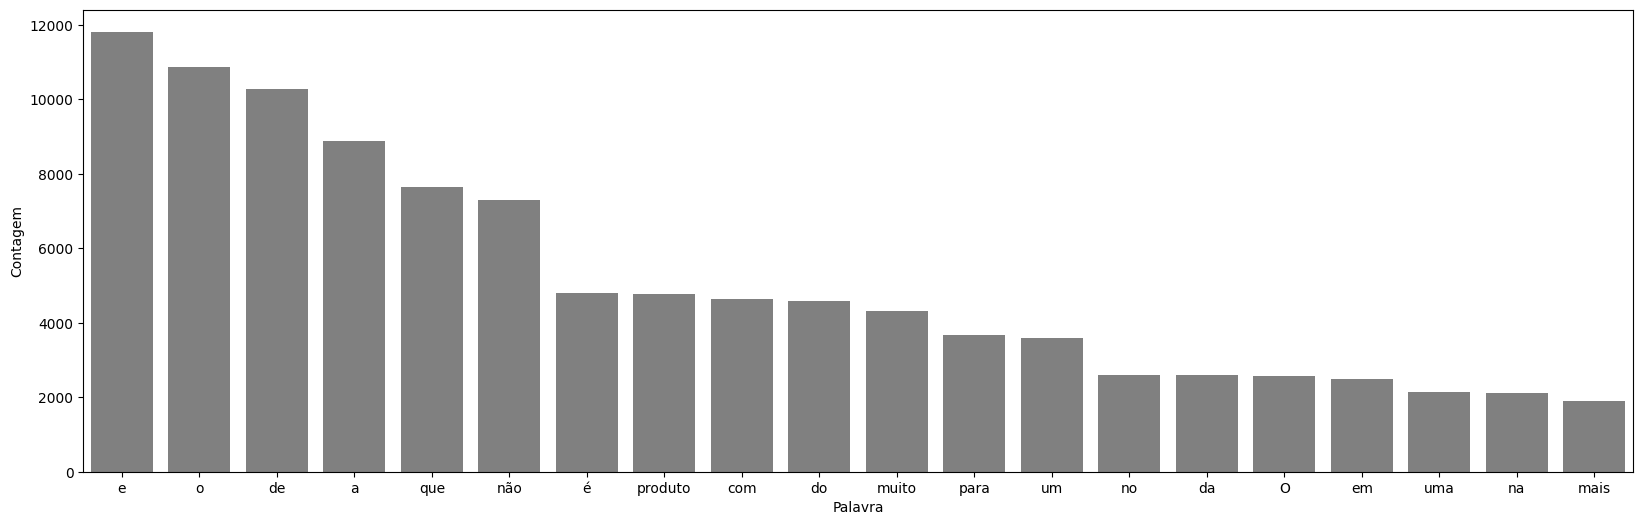

In [75]:
grafico_frequencia(df, 'avaliacao', 20)